# Домашнее задание 3. Анализ данных

Задание выполнил(а):

    Городнов Даниил

# Часть I

Каждое задание в этой части оценивается в 0,15 баллов. Всего за выполнение этой части можно получить 2,55 балла.

In [151]:
import pandas as pd
import seaborn as sns
from scipy.stats import norm

In [152]:
DIABETS = 'https://raw.githubusercontent.com/evgpat/datasets/main/pima_indians_diabetes.csv'
BABIES = 'https://raw.githubusercontent.com/evgpat/datasets/main/babies_all.txt'

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [153]:
data = pd.read_csv(DIABETS)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

## Задание 1

Как вы видите, в данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

**"В переменной {название переменной} {количество} пропущенных значений"**

In [154]:
for i in data.columns:
  print(f'В переменной {i} {data[i].isnull().sum()} пропущенных значений')

В переменной Pregnancies 0 пропущенных значений
В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений
В переменной DiabetesPedigreeFunction 0 пропущенных значений
В переменной Age 0 пропущенных значений
В переменной Class 0 пропущенных значений


## Задание 2

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [155]:
for i in data.columns:
  if data[i].dtype == 'int64':
    data[i] = data[i].fillna(data[i].mean())
  elif data[i].dtype == 'float64':
    data[i] = data[i].fillna(data[i].median())

In [156]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Class                     768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


## Задание 3

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [157]:
for d in data.columns:
  print('-------------------------------------------')
  print(f'статистики для {d}')
  print('-------------------------------------------')
  print(data[d].describe())

-------------------------------------------
статистики для Pregnancies
-------------------------------------------
count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64
-------------------------------------------
статистики для Glucose
-------------------------------------------
count    768.000000
mean     121.656250
std       30.438286
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64
-------------------------------------------
статистики для BloodPressure
-------------------------------------------
count    768.000000
mean      72.386719
std       12.096642
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64
-------------------------------------------
статистики для SkinThickness
----

## Задание 4

У скольких женщин строго старше 50 лет обнаружен диабет?

In [158]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [159]:
diabet = sum((data['Age'] > 50) & (data['Class'] == 1))
diabet

38

## Задание 5

Найдите трех женщин с наибольшими числом беременностей.

In [160]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print('я так понял это (( ͡° ͜ʖ ͡°)づ ━━ ✫・*) не надо убирать?)')

я так понял это (( ͡° ͜ʖ ͡°)づ ━━ ✫・*) не надо убирать?)


In [161]:
# Для этого задания я добавлю столбец где цифра будет означать одного челоовека

In [162]:
data['woman'] = range(1,len(data)+1)

In [163]:
data.sort_values('Pregnancies', ascending=False).iloc[:3]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,woman
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1,160
88,15,136.0,70.0,32.0,110.0,37.1,0.153,43,1,89
455,14,175.0,62.0,30.0,125.0,33.6,0.212,38,1,456


## Задание 6

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

In [164]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
sum((data['Age'] > 30)&((data['Age'] < 40))&(data['Pregnancies'] >= 3))

115

## Задание 7

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [165]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
(sum((data['BloodPressure']>=80)&(data['BloodPressure']<=89)))/(sum(data['BloodPressure']))

0.0026082420448617634

## Задание 8

Считается, что BMI >= 30 - это признак ожирения.
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [166]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
mean_blood = data['BloodPressure'].mean()
sum((data['BMI']>=30)&(data['BloodPressure'] > mean_blood))

251

## Задание 9

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [167]:
# Glucose ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_diabel = data[data['Class'] == 1]
data_nodiabet = data[data['Class'] == 0]

print(f'средний уровень глюкозы у диабетиков {data_diabel['Glucose'].mean()}')
print(f'средний уровень глюкозы у не диабетиков {data_nodiabet['Glucose'].mean()}')

средний уровень глюкозы у диабетиков 142.13059701492537
средний уровень глюкозы у не диабетиков 110.682


In [168]:
# BloodPressure ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(f'средний уровень кровенного давления у диабетиков {data_diabel['BloodPressure'].mean()}')
print(f'средний уровень кровенного давления у не диабетиков {data_nodiabet['BloodPressure'].mean()}')

средний уровень кровенного давления у диабетиков 75.1231343283582
средний уровень кровенного давления у не диабетиков 70.92


In [169]:
# Insulin ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(f'средний уровень инсулина у диабетиков {data_diabel['Insulin'].mean()}')
print(f'средний уровень инсулина у не диабетиков {data_nodiabet['Insulin'].mean()}')

средний уровень инсулина у диабетиков 164.70149253731344
средний уровень инсулина у не диабетиков 127.792


## Задание 10

Постройте гистограммы для любых двух количественных признаков.

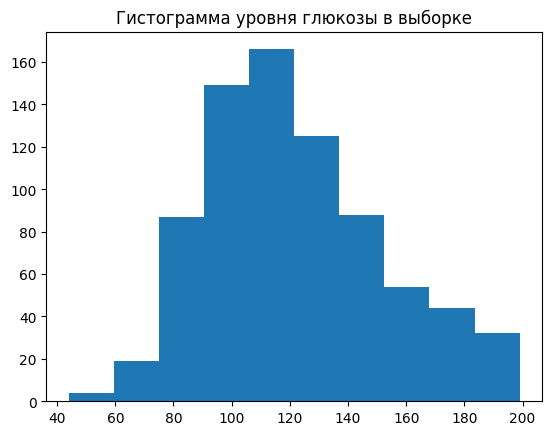

In [170]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
import matplotlib.pyplot as plt

plt.hist(data['Glucose'])
plt.title('Гистограмма уровня глюкозы в выборке')
plt.show()

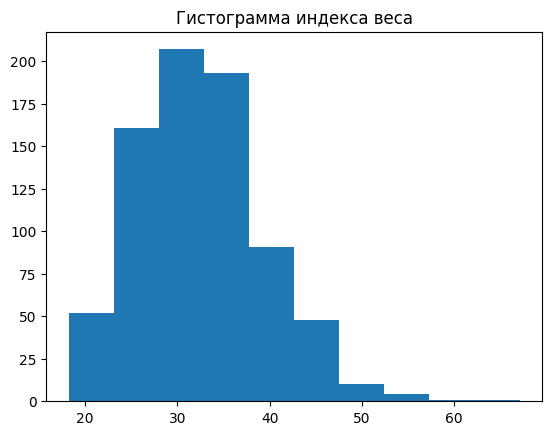

In [171]:
plt.hist(data['BMI'])
plt.title('Гистограмма индекса веса')
plt.show()

In [172]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,woman
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,3
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,4
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5


## Задание 11

Постройте круговую диаграмму для признака __Class__.

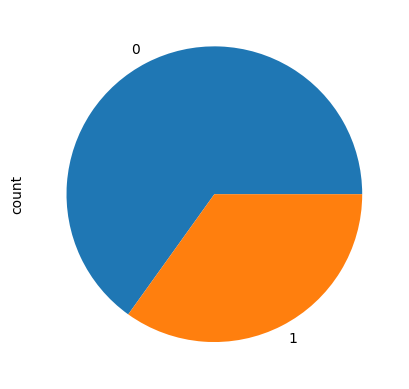

In [173]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data['Class'].value_counts().plot(kind='pie')
plt.show()

## Задание 12

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)

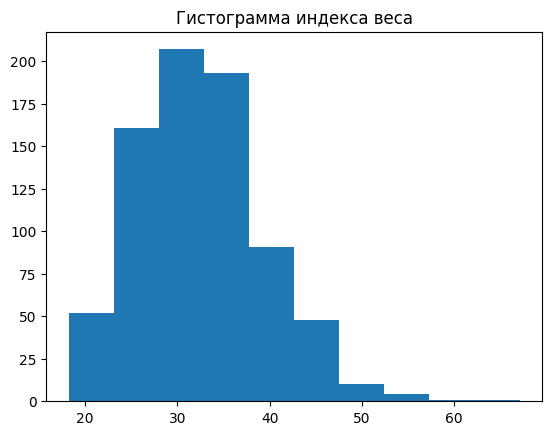

In [174]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
plt.hist(data['BMI'])
plt.title('Гистограмма индекса веса')
plt.show()

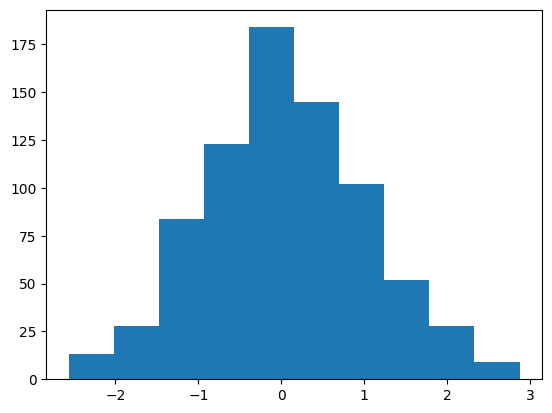

In [175]:
import numpy as np
x = np.random.normal(loc=0, scale=1, size=768)
plt.hist(x)
plt.show()

In [176]:
print('Распределение BMI смещено влево, и имеет тяжелый левый хвост, поэтому его сложно назвать нормальным. В любом случае все визуальные проверки стоит подкреплять критериями согласия')

Распределение BMI смещено влево, и имеет тяжелый левый хвост, поэтому его сложно назвать нормальным. В любом случае все визуальные проверки стоит подкреплять критериями согласия


Постройте нормальное распределение поверх графика.

In [177]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

## Задание 13

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

In [178]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,woman
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,3
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,4
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5


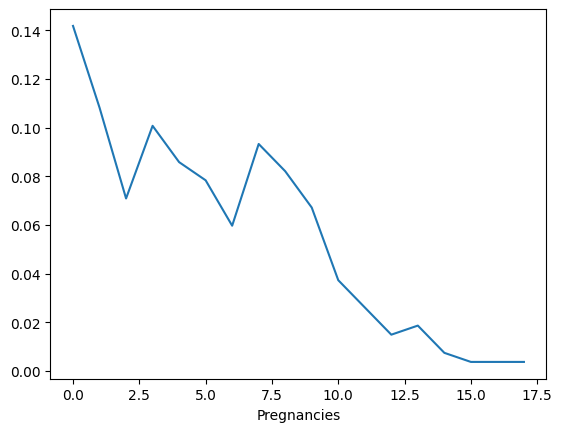

In [179]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
grafic = data.groupby('Pregnancies')['Class'].sum()/sum(data['Class'])
grafic.plot()
plt.show()

## Задание 14

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [180]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data['wasPregnant'] = np.where(data['Pregnancies'] > 0, 1, 0)
data['wasPregnant'].head()

,wasPregnant
0,1
1,1
2,1
3,1
4,0


## Задание 15

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [181]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,woman,wasPregnant
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,3,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,4,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5,0


In [182]:
data.groupby('wasPregnant')['Class'].sum()

,Class
wasPregnant,
0,38
1,230


## Задание 16

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [183]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
type_body = []
for ves in data['BMI']:
    if ves < 18.5:
        type_body.append('Underweight')
    elif ves < 25:
        type_body.append('Normal weight')
    elif ves < 30:
        type_body.append('Overweight')
    else:
        type_body.append('Obesity')

data['bodyType'] = type_body

In [184]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,woman,wasPregnant,bodyType
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1,1,Obesity
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2,1,Overweight
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,3,1,Normal weight
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,4,1,Overweight
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5,0,Obesity


## Задание 17

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [185]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
healthy = data[(data['bodyType'] == 'Normal weight')&(data['BloodPressure'].between(80, 89))]
result = healthy['Class'].value_counts()/len(healthy) * 100
result

,count
Class,
0,90.0
1,10.0


# Часть II

Каждое задание в этой части оценивается в 1,15 баллов. Всего за выполнение этой части можно получить 3,45 балла.

In [186]:
babies = pd.read_csv(BABIES, index_col=0)
babies.head(10)

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


## Задание 1

Исследуйте набор данных `babies`. Ответьте на вопросы.

1. Какие годы включает датасет

2. Какое имя в датасете находится по индексом 121?

3. Cколько всего родилось детей по имени 'Aaron' за все время?

4. Насколько больше за все время родилось мальчиков чем девочек?

5. Cколько мальчиков родилось в 2010?

6. Сколько в датасете девочек по имени John?

In [187]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(f'от {babies['year'].min()} до {babies['year'].max()}')

от 1880 до 2010


In [188]:
babies['name'].iloc[121]

'Ann'

In [189]:
aron = 0
for ar in babies['name']:
  if ar == 'Aaron':
    aron += 1

aron

212

In [190]:
men = len(babies[babies['sex'] == 'M'])
women = len(babies[babies['sex'] == 'F'])

print(men)
print(women)

coun = men - women
coun

686799
1003985


-317186

In [191]:
df_2010 = babies[babies['year'] == 2010]
print(len(df_2010[df_2010['sex'] == 'M']))

14140


In [192]:
women_df = babies[babies['sex'] == 'F']

john = 0
for jo in women_df['name']:
  if jo == 'John':
    john += 1

john

131

В итоге датасет с 1880 по 2010 год, любопытно где бы брали данные за 19 век и почти весь 20-й.

Под индексом 121 находится имя 'Ann'

В датасете 212 детей по имени Aaron

В датасете женщин родилось больше чем мужчин на 317186

В 2010 году родилось 14140 мальчиков

В датасете девочек по имени Джон 131. Возможно это какая-то ошибка или гендерные особенности некоторых стран. Или есть такое женское имя

## Задание 2

1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.

2. Создайте фигуру matplotlib с 3 графиками один под другим.

3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.

4. Верхняя и правая границы графиков должны быть невидимы, к каждому графику должен быть заголовок, третий график должен содержать легенду, шкалы графиков должны быть подписаны.

5. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

6. Кратко опишите тренды в ячейке markdown под графиками.

Если при группировке вы сделали год индексом, то можно обратиться к значениям этой переменной через аттрибут `.index`

In [193]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
help_df = babies[['sex','number','year']]
all = help_df.groupby(['year'])['number'].sum().reset_index()
baby_boys = help_df[help_df['sex'] == 'M'].groupby(['year'])['number'].sum().reset_index()
baby_girls = help_df[help_df['sex'] == 'F'].groupby(['year'])['number'].sum().reset_index()

In [194]:
import matplotlib.pyplot as plt

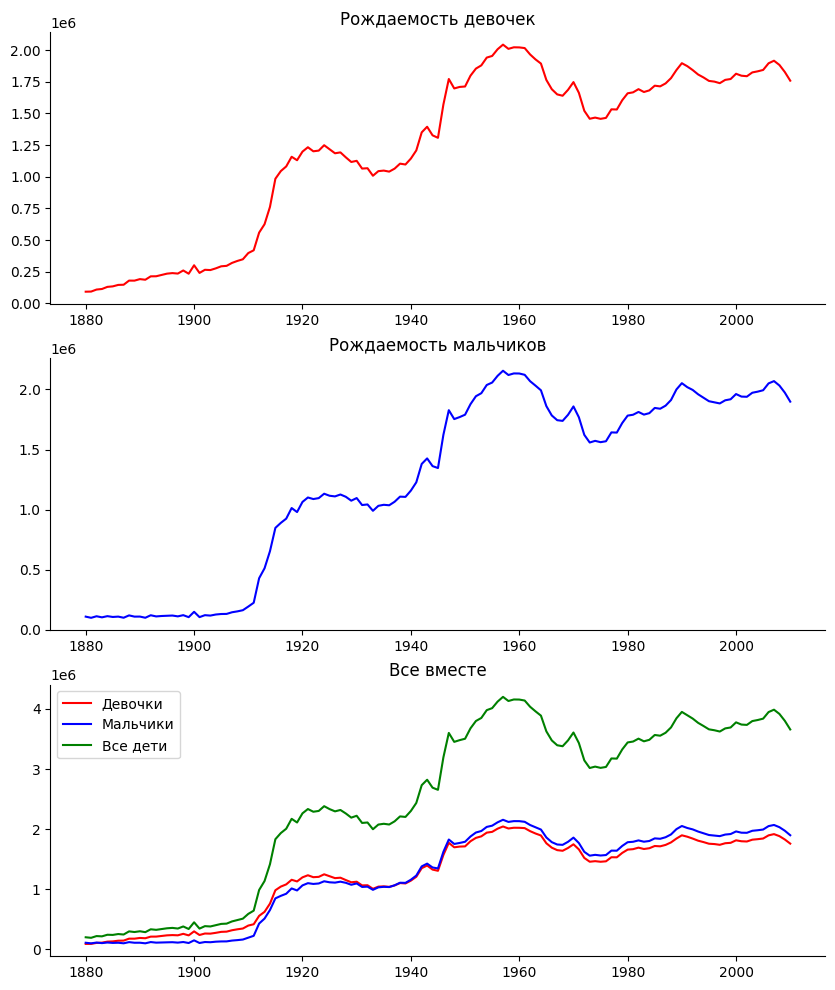

In [195]:
grafic, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(baby_girls['year'], baby_girls['number'], color='red')
axes[0].set_title('Рождаемость девочек')

axes[1].plot(baby_boys['year'], baby_boys['number'], color='blue')
axes[1].set_title('Рождаемость мальчиков')

axes[2].plot(baby_girls['year'], baby_girls['number'], color='red', label='Девочки')
axes[2].plot(baby_boys['year'], baby_boys['number'], color='blue', label='Мальчики')
axes[2].plot(all['year'], all['number'], color='green', label='Все дети')
axes[2].set_title('Все вместе')
axes[2].legend()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.show()

Сильной разницы между рождаемостью мальчиков и девочек в данных нет (и не должно быть наверное), есть только общий тренд. Происходили демографические взрывы в 1918 и в 1945 годах. Это обусловлено окончанием Первой Мировой войны и окончанием Второй Мировой войны

## Задание 3

1. Сгруппируйте нужным способом датафрейм babies и найдите 4 самых популярных имени за всю историю (2 женских и 2 мужских).

2. Для каждого найденного имени создайте новый датафрейм вида babies_alisa и сохраните в него данные, сколько детей с таким именем рождалось каждый год.

3. Создайте фигуру matplotlib с 4 горизонтальными графиками один под другим.

4. Постройте 4 линейных графика - тренд для каждого имени за все время.

5. Каждый график должен содержать легенду, один общий заголовок, шкалы графиков должны быть подписаны.

6. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

7. Опишите тренды в ячейке markdown под графиками.

In [196]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
men_3 = babies[babies['sex'] == 'M']
women_3 = babies[babies['sex'] == 'F']
men_grouped = men_3.groupby('name')['number'].sum().reset_index()
women_grouped = women_3.groupby('name')['number'].sum().reset_index()

In [197]:
two_name_men = men_grouped.sort_values('number', ascending=False).head(2)
name_first_m = two_name_men['name'].iloc[0]
name_second_m = two_name_men['name'].iloc[1]
two_name_men

,name,number
15399,James,5049727
17267,John,5040319


In [198]:
two_name_women = women_grouped.sort_values('number', ascending=False).head(2)
name_first_w = two_name_women['name'].iloc[0]
name_second_w = two_name_women['name'].iloc[1]
two_name_women

,name,number
38095,Mary,4103935
44211,Patricia,1568742


In [199]:
babies_james = men_3[men_3['name'] == name_first_m]
babies_john = men_3[men_3['name'] == name_second_m]
babies_mary = women_3[women_3['name'] == name_first_w]
babies_patricia = women_3[women_3['name'] == name_second_w]

In [200]:
babies_james = babies_james[['year','number']]
babies_john = babies_john[['year','number']]
babies_mary = babies_mary[['year','number']]
babies_patricia = babies_patricia[['year','number']]

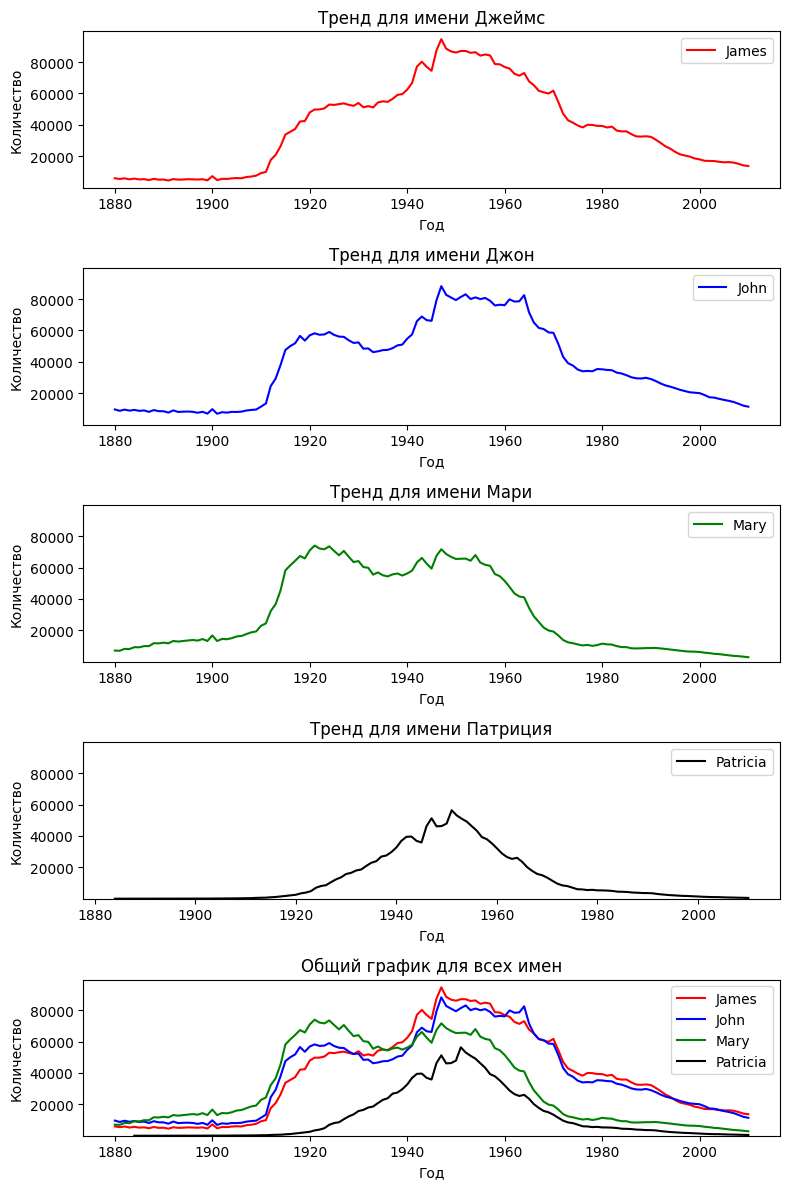

In [201]:
grafic_2, axes = plt.subplots(5,1, figsize=(8,12))

axes[0].plot(babies_james['year'], babies_james['number'], color='red')
axes[0].set_title('Тренд для имени Джеймс')
axes[0].legend(['James'])

axes[1].plot(babies_john['year'], babies_john['number'], color='blue')
axes[1].set_title('Тренд для имени Джон')
axes[1].legend(['John'])

axes[2].plot(babies_mary['year'], babies_mary['number'], color='green')
axes[2].set_title('Тренд для имени Мари')
axes[2].legend(['Mary'])

axes[3].plot(babies_patricia['year'], babies_patricia['number'], color='black')
axes[3].set_title('Тренд для имени Патриция')
axes[3].legend(['Patricia'])

axes[4].plot(babies_james['year'], babies_james['number'], color='red')
axes[4].plot(babies_john['year'], babies_john['number'], color='blue')
axes[4].plot(babies_mary['year'], babies_mary['number'], color='green')
axes[4].plot(babies_patricia['year'], babies_patricia['number'], color='black')
axes[4].set_title('Общий график для всех имен')
axes[4].legend(['James', 'John', 'Mary', 'Patricia'])

data_list = [babies_james['number'], babies_john['number'],
             babies_mary['number'], babies_patricia['number']]
y_min = min(df.min() for df in data_list)
y_max = max(df.max() for df in data_list) + 5000
for ax in axes:
    ax.set_ylim(y_min, y_max)

for podpis in axes:
  podpis.set_xlabel('Год')
  podpis.set_ylabel('Количество')

plt.tight_layout()
plt.show()


Тренд для трех имен (Джон, Джеймс, Мари) достаточно похожий, и он скорее связан не с популярностью этих имен (хотя она тоже есть), а с демографическими взрывами рождаемости в эти периоды. Что касается имени Патриция, то здесь свой тренд, резкий взлет популярности к 1950 году.

## Часть III

Каждое задание в этой части оценивается в 0,2 балла. Всего за выполнение этой части можно получить 4 балла.

Вам предлагается проанализировать датасет с Data - вакансиями.  
Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью `pd.read_csv`.




In [202]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
df_vac = pd.read_csv('/content/sample_data/vacancies.csv')
df_vac.head(10)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"
5,5,Data Scientist,China Good Car,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Дата-сайентист,"{'from': 450000, 'to': 'null', 'currency': 'KZ...",<strong>Обязанности:</strong> <p>- Проектирова...,"['Python', 'Обработка естественного языка (NLP..."
6,6,Стажер Data Scientist,WILDBERRIES,Москва,Нет опыта,Полный день,Стажировка,Дата-сайентист,NaN,<p>Начни свою карьеру в Wildberries!</p> <p>Мы...,[]
7,7,Стажер - Data Scientist,Эр-1,Пермь,Нет опыта,Удаленная работа,Стажировка,Дата-сайентист,NaN,<p><strong>R1</strong> — это новый взгляд на п...,[]
8,8,Аналитик данных/ data analyst,Skillzania,Москва,От 1 года до 3 лет,Удаленная работа,Полная занятость,"BI-аналитик, аналитик данных","{'from': 80000, 'to': 'null', 'currency': 'RUR...",<p><strong>Группа компаний SKILLZANIA это:<br ...,[]
9,9,Аналитик данных/ Data analyst,Bereke Bank,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Обязанности:</strong> <ul> <li>Поддерж...,[]


1. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы `info` и `describe`. Сколько в датасете строк и столбцов?

In [203]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(df_vac.info())
print('=========================================================================')
print(df_vac.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1527 non-null   int64 
 1   position_name       1527 non-null   object
 2   employer_name       1527 non-null   object
 3   area                1527 non-null   object
 4   experience          1527 non-null   object
 5   schedule            1527 non-null   object
 6   employment          1527 non-null   object
 7   professional_roles  1527 non-null   object
 8   salary              220 non-null    object
 9   description         1527 non-null   object
 10  key_skills          1527 non-null   object
dtypes: int64(1), object(10)
memory usage: 131.4+ KB
None
        Unnamed: 0
count  1527.000000
mean    763.000000
std     440.951244
min       0.000000
25%     381.500000
50%     763.000000
75%    1144.500000
max    1526.000000


In [204]:
df_vac.head()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


In [205]:
df_vac.tail()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."
1526,1526,Senior Python Developer (Data Platform),Mindbox,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."


В датасете 11 столбцов (один лишний), и 1527 строк

2. Есть ли в датасете пропуски?

In [206]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
df_vac.isnull().sum()

,0
Unnamed: 0,0
position_name,0
employer_name,0
area,0
experience,0
schedule,0
employment,0
professional_roles,0
salary,1307
description,0


В датасете есть пропусти только в столбце зарплата

3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates).

In [207]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
df_vac.duplicated().sum()

np.int64(0)

В датасете нет полных дублей

4. Сколько уникальных значений у переменной professional_roles?

In [208]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
len(df_vac['professional_roles'].unique())

36

36 униикальных значений

5. Сколько в датасете вакансий, не требующих опыта?

In [209]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
len(df_vac[df_vac['experience'] == 'Нет опыта'])

136

136 вакансий не требующих опыта

6. Какое среднее количество навыков в вакансии? (переменная key_skills)

In [210]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
df_vac['key_skills'].str.split(',').str.len().mean()

np.float64(4.276358873608382)

Среднее кол-во навыков 4,27, то есть 4-5 навыков

7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [211]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
curr = []
for sal in df_vac['salary']:
    if pd.isnull(sal):
        curr.append(np.nan)
    else:
        salary_dict = eval(sal)
        curr.append(salary_dict['currency'])

df_vac['currency'] = curr

In [212]:
df_vac.head(5)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",NaN
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],NaN
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT


8. Какая компания лидирует по количеству вакансий?

In [213]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
df_lid = df_vac['employer_name'].value_counts()
df_lid = pd.DataFrame(df_lid).reset_index()
df_lid.sort_values('count', ascending=False).head(1)

,employer_name,count
0,СБЕР,146


9.  Какая компания лидирует по количеству вакансий с указанием заработной платы?

In [214]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
df_lid_sl = df_vac[df_vac['salary'] != np.nan]
df_lid_sl = df_lid_sl['employer_name'].value_counts()
df_lid_sl = pd.DataFrame(df_lid_sl).reset_index()
df_lid_sl.sort_values('count', ascending=False).head(1)

,employer_name,count
0,СБЕР,146


тут абсолютно также

10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [215]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
salari = []
for s in df_vac['salary']:
    if pd.isnull(s):
        salari.append(None)
    else:
        d = eval(s)
        from_val = d.get('from')
        to_val = d.get('to')

        try:
            from_val = float(from_val) if from_val is not None else None
        except:
            from_val = None
        try:
            to_val = float(to_val) if to_val is not None else None
        except:
            to_val = None

        if from_val and to_val:
            salari.append((from_val + to_val) / 2)
        elif from_val:
            salari.append(from_val)
        elif to_val:
            salari.append(to_val)

df_vac['salary_num'] = salari

In [216]:
df_vac

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",NaN,NaN
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],NaN,NaN
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT,950000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch...",NaN,NaN
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[],NaN,NaN
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[],NaN,NaN
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra...",NaN,NaN


11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  

In [217]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。


print(f'Средняя зарплата в датасете {df_vac['salary_num'][df_vac['currency'] == 'RUR'].mean()}')
print(f'Средняя зарплата в датасете {df_vac['salary_num'][df_vac['currency'] == 'RUR'].median()}')

Средняя зарплата в датасете 212395.02762430938
Средняя зарплата в датасете 200000.0


12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python?

In [218]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
python_count = 0
for sk in df_vac['key_skills']:
    if 'Python' in sk or 'python' in sk:
      python_count += 1

python_count


633

In [219]:
python_one = []

for skills in df_vac['key_skills']:
    if skills and 'python' in str(skills).lower():
        python_one.append(1)
    else:
        python_one.append(0)

df_vac['is_python_requirement'] = python_one
df_vac

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num,is_python_requirement
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0,0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0,0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",NaN,NaN,1
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],NaN,NaN,0
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT,950000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch...",NaN,NaN,1
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[],NaN,NaN,0
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[],NaN,NaN,0
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra...",NaN,NaN,1


In [220]:
len(df_vac[df_vac['is_python_requirement']==1])/len(df_vac['is_python_requirement'])

0.41453831041257366

Примерно 41.5% вакансий требуют знание python

13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях


In [221]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  

In [222]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
count_skil = []

for i in df_vac['key_skills']:
    if i != '[]':
      dlina = eval(i)
      count_skil.append(len(dlina))
    else:
      count_skil.append(0)

df_vac['count_skills'] = count_skil

In [223]:
df_vac.head()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num,is_python_requirement,count_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0,0,0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0,0,0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",NaN,NaN,1,11
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],NaN,NaN,0,0
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT,950000.0,0,2


15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [224]:
import re

def get_len_descr(descr):
  if pd.isnull(descr):
    return 0
  else:
    clean = re.sub(r'<[^>]*>', '', str(descr))
    return len(clean)

df_vac['len_descr'] = df_vac['description'].apply(get_len_descr)

In [225]:
df_vac.head()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num,is_python_requirement,count_skills,len_descr
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0,0,0,1583
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0,0,0,1310
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",NaN,NaN,1,11,3760
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],NaN,NaN,0,0,1188
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT,950000.0,0,2,3355


16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  

In [226]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
corr = df_vac[['salary_num', 'len_descr', 'count_skills']].corr()
corr

,salary_num,len_descr,count_skills
salary_num,1.000000,0.001213,-0.011834
len_descr,0.001213,1.000000,0.126813
count_skills,-0.011834,0.126813,1.000000


In [227]:
corr_sp = df_vac[['salary_num', 'len_descr', 'count_skills']].corr(method='spearman')
corr_sp

,salary_num,len_descr,count_skills
salary_num,1.000000,0.029663,-0.080323
len_descr,0.029663,1.000000,0.122734
count_skills,-0.080323,0.122734,1.000000


17. Постройте тепловую карту из таблицы из предыдущего пункта.

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。